# Phase 2 — Image Analytics for EV-Bus Brand Optimization (end-to-end)

**One consolidated notebook** covering the full image pipeline:

1. **Low-level features** — brightness, saturation, contrast, sharpness, warm/cool hue, dominant colours, colourfulness, edge density, symmetry, rule-of-thirds, visual balance, figure-ground separation
2. **High-level features** — BLIP caption + DETR object detection + CLIP zero-shot for bus/driver/passenger visibility, charger/depot, wheelchair-ramp/low-floor access, bus-in-motion, fleet-scale deployment, government handover, urban/natural setting, product-showcase-vs-operational-proof, and technology/comfort/trust/sustainability themes
3. **Text** — Tesseract OCR + VADER narrative-framing sentiment + LDA topics
4. **Perception scores** — CLIP zero-shot **proxy** for 7 dimensions (trust, modernity, comfort, accessibility, environmental-friendliness, operational-readiness, visual-appeal) **plus** a blank human/independent-coder template
5. **Feature → perception relationships** — the five spec hypotheses, tested

> All heavy logic lives in `scripts/pipeline_lib.py` (lazy-loaded, cached models) so this notebook stays readable. Outputs are written to `data/`, `outputs/charts/`, `outputs/reports/`.


In [1]:
import sys, json
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
sns.set_style("whitegrid")
%matplotlib inline

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "scripts"))
import pipeline_lib as L

IMAGES  = ROOT / "images"
DATA    = ROOT / "data";              DATA.mkdir(exist_ok=True)
CHARTS  = ROOT / "outputs" / "charts"; CHARTS.mkdir(parents=True, exist_ok=True)
REPORTS = ROOT / "outputs" / "reports";REPORTS.mkdir(parents=True, exist_ok=True)
print("images:", len(L.iter_images(IMAGES)), "| device:", L._device())

images: 39 | device: cpu


## 1–2. Extract low-level + high-level features (per image)

`build_dataframe` runs, for every image: the 12 OpenCV/NumPy low-level metrics, a BLIP caption, DETR object detection (COCO bus/person/truck counts), CLIP zero-shot for every high-level attribute + theme + perception proxy, and Tesseract OCR. First run downloads BLIP/DETR/CLIP (~2 GB, cached afterwards).

In [2]:
df = L.build_dataframe(IMAGES, verbose=True)
print("\nmaster table:", df.shape)
df.head(3)

Loading weights:   0%|          | 0/530 [00:00<?, ?it/s]

Loading weights:  23%|██▎       | 122/530 [00:00<00:00, 1218.77it/s]

Loading weights:  46%|████▌     | 244/530 [00:00<00:00, 1006.68it/s]

Loading weights:  65%|██████▌   | 347/530 [00:00<00:00, 884.58it/s] 

Loading weights:  83%|████████▎ | 438/530 [00:00<00:00, 832.82it/s]

...

  [36/39] switch (  bus=0 person=0 setting=indoor_studio    | a bus with blue seats and yellow trims


  [37/39] switch (  bus=0 person=0 setting=indoor_studio    | a bus with yellow and blue seats


  [38/39] switch (  bus=0 person=0 setting=indoor_studio    | a car with a steering and a steering wheel


  [39/39] switch (  bus=0 person=4 setting=indoor_studio    | a bus with yellow and blue seats

master table: (39, 60)


,image_id,file_path,width,height,aspect_ratio,file_size_kb,brightness,contrast,saturation,sharpness,...,pxy_comfort,pxy_accessibility,pxy_env_friendliness,pxy_operational_readiness,pxy_visual_appeal,hl_setting,hl_setting_conf,hl_bus_visible,hl_passenger_driver_visible,hl_fleet_scale_deploy
0,053e8112-6bf8-4fd4-8691-8a1bd8a58a1f,images/053e8112-6bf8-4fd4-8691-8a1bd8a58a1f.JPG,1030,1033,0.997,126.6,24.14,58.94,40.80,481.39,...,76.2,8.4,4.0,55.8,99.3,infographic_text,0.966,False,False,False
1,1c3f1cbe-665c-49c9-86db-ee0cb7cc5e2e,images/1c3f1cbe-665c-49c9-86db-ee0cb7cc5e2e.JPG,592,799,0.741,144.3,96.72,73.90,101.48,888.44,...,88.9,70.8,69.6,57.0,98.9,indoor_studio,0.640,True,True,False
2,1d4a1664-699d-4488-8634-f6bdd8553a08,images/1d4a1664-699d-4488-8634-f6bdd8553a08.JPG,613,867,0.707,155.3,142.46,80.92,47.02,4718.34,...,98.1,94.7,70.0,26.9,92.4,indoor_studio,0.542,True,False,True


### Low-level feature summary

In [3]:
lowlevel = ["brightness","contrast","saturation","sharpness","warm_cool_bias","colourfulness",
            "edge_density","symmetry_h","symmetry_v","rule_of_thirds","visual_balance",
            "figure_ground_sep","aspect_ratio"]
df[lowlevel].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
brightness,39.0,105.67,60.59,19.92,62.72,96.72,139.72,216.10
contrast,39.0,66.54,11.40,48.55,59.03,63.59,74.78,89.72
saturation,39.0,63.58,41.26,4.73,34.64,62.59,84.51,164.54
sharpness,39.0,1980.78,2196.96,201.76,455.36,845.05,3400.02,6638.78
warm_cool_bias,39.0,-0.02,0.09,-0.31,-0.06,-0.01,0.02,0.18
colourfulness,39.0,46.71,20.44,11.81,32.78,47.01,59.36,95.89
edge_density,39.0,0.08,0.05,0.03,0.05,0.07,0.10,0.19
symmetry_h,39.0,0.82,0.05,0.69,0.79,0.82,0.85,0.90
symmetry_v,39.0,0.74,0.08,0.57,0.69,0.73,0.79,0.89
rule_of_thirds,39.0,0.44,0.09,0.27,0.37,0.45,0.48,0.62


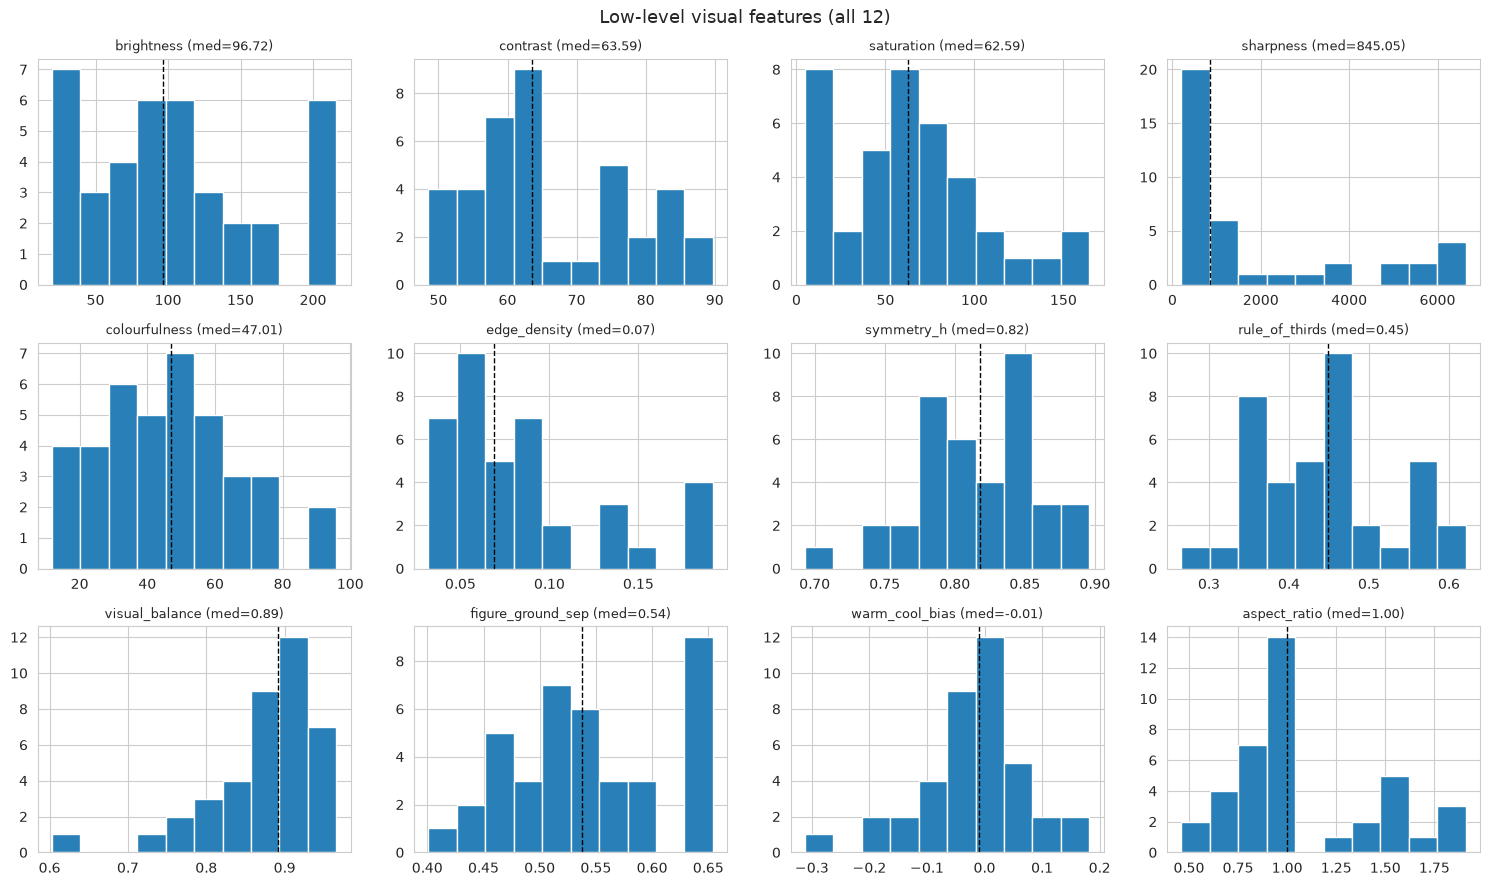

In [4]:
feats = ["brightness","contrast","saturation","sharpness","colourfulness","edge_density",
         "symmetry_h","rule_of_thirds","visual_balance","figure_ground_sep","warm_cool_bias","aspect_ratio"]
fig, axs = plt.subplots(3, 4, figsize=(15, 9))
for ax, c in zip(axs.ravel(), feats):
    ax.hist(df[c].dropna(), bins=10, color="#2980b9", edgecolor="white")
    ax.axvline(df[c].median(), color="k", ls="--", lw=1)
    ax.set_title(f"{c} (med={df[c].median():.2f})", fontsize=9)
fig.suptitle("Low-level visual features (all 12)", fontsize=13)
plt.tight_layout(); plt.savefig(CHARTS/"fig_feature_distributions.png", dpi=140); plt.show()

### High-level features (BLIP + DETR + CLIP)

In [5]:
hl_cols = ["image_id","hl_setting","obj_bus_count","obj_person_count","hl_bus_visible",
           "hl_passenger_driver_visible","hl_charger_depot_flag","hl_accessibility_flag",
           "hl_bus_in_motion_flag","hl_fleet_scale_deploy","hl_govt_handover_flag",
           "hl_operational_proof_flag","blip_caption"]
df[hl_cols].head(10)

,image_id,hl_setting,obj_bus_count,obj_person_count,hl_bus_visible,hl_passenger_driver_visible,hl_charger_depot_flag,hl_accessibility_flag,hl_bus_in_motion_flag,hl_fleet_scale_deploy,hl_govt_handover_flag,hl_operational_proof_flag,blip_caption
0,053e8112-6bf8-4fd4-8691-8a1bd8a58a1f,infographic_text,0,0,False,False,False,False,False,False,False,True,open the bang set the story shifts
1,1c3f1cbe-665c-49c9-86db-ee0cb7cc5e2e,indoor_studio,1,1,True,True,False,False,False,False,True,False,"tata motors, tata motors, tata motors, tata mo..."
2,1d4a1664-699d-4488-8634-f6bdd8553a08,indoor_studio,3,0,True,False,True,True,False,True,True,True,a bus with a large number of passengers
3,25365fed-8fba-470c-8f75-785311727ab1,infographic_text,0,0,False,False,False,False,False,False,True,False,"the game ' s menu, with the same text"
4,55cba8f5-ec0a-4822-8a64-7e1585d14eb9,infographic_text,2,2,True,True,True,False,True,False,True,True,tata electric vehicles and electric vehicles
5,578aeaf6-7b83-4995-87c9-6216a5dc01fb,urban,4,1,True,True,False,False,False,True,True,True,a bunch of buses parked on the side of a road
6,590566b4-289d-4df5-a1a3-912e312dd762,infographic_text,1,0,True,False,False,False,False,False,False,True,the front page of the german newspaper
7,6120605a-1c59-46b7-b81f-dfd785ea1e5c,infographic_text,1,2,True,True,False,False,True,False,True,False,"a bus driving down a road with the words, ' th..."
8,65a3f5bc-b7c7-44e4-a291-5dbd70cd7ca2,infographic_text,1,0,True,False,False,False,False,False,True,False,a newspaper article with a bus and a bus
9,6f3fe3a7-5eb8-4c20-ae85-339fa4997a97,infographic_text,1,1,True,True,False,False,True,False,True,False,the electric bus is driving down the road


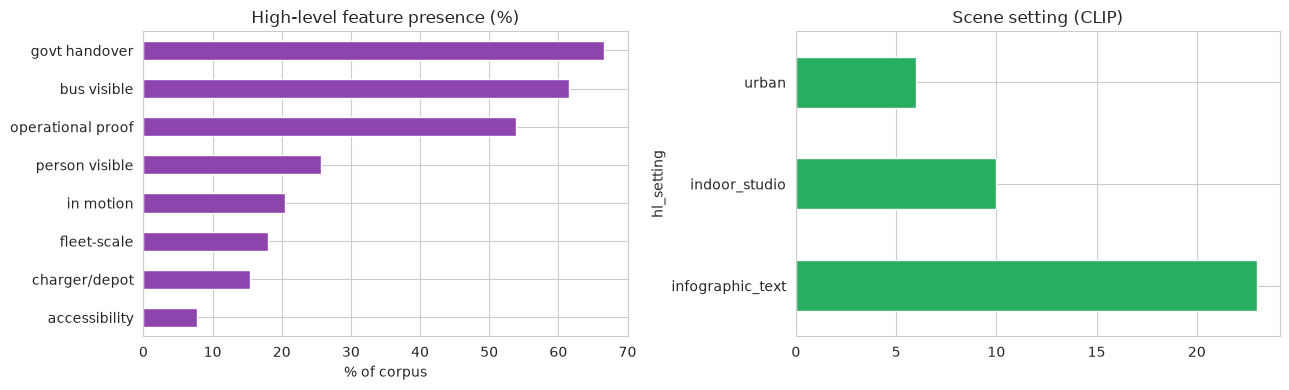

In [6]:
flags = {"bus visible":"hl_bus_visible","person visible":"hl_passenger_driver_visible",
         "charger/depot":"hl_charger_depot_flag","accessibility":"hl_accessibility_flag",
         "in motion":"hl_bus_in_motion_flag","fleet-scale":"hl_fleet_scale_deploy",
         "govt handover":"hl_govt_handover_flag","operational proof":"hl_operational_proof_flag"}
rates = {k: 100*df[v].mean() for k,v in flags.items()}
fig, ax = plt.subplots(1, 2, figsize=(13,4))
pd.Series(rates).sort_values().plot(kind="barh", color="#8e44ad", ax=ax[0]); ax[0].set_title("High-level feature presence (%)"); ax[0].set_xlabel("% of corpus")
df["hl_setting"].value_counts().plot(kind="barh", color="#27ae60", ax=ax[1]); ax[1].set_title("Scene setting (CLIP)")
plt.tight_layout(); plt.savefig(CHARTS/"fig_high_level_flags.png", dpi=140); plt.show()

## 3. Text — OCR + narrative-framing sentiment + LDA topics

In [7]:
df = L.add_sentiment(df)
topics = L.lda_topics(df)
print("OCR coverage:", int(100*(df["ocr_char_len"]>0).mean()), "%")
print("sentiment mix:", df["nf_label"].value_counts().to_dict())
for k, top in topics: print(f"Topic {k}:", ", ".join(top))

OCR coverage: 74 %
sentiment mix: {'positive': 18, 'no_text': 10, 'negative': 7, 'neutral': 4}
Topic 0: buses, tender, electric, bus, mobility, eka, tata, volvo, motors, drive
Topic 1: tata, bus, motors, electric, vecv, tender, buses, mobility, india, said
Topic 2: bus, buses, delhi, sales, units, year, india, public, charging, period


## 4. Perception scores

Two tracks, kept separate on purpose:

- **`pxy_*` (0-100)** — automated **CLIP zero-shot proxy** for each of the 7 dimensions. Available now, used for the relationship tests below.
- **`coder_*`** — a **blank template** (`data/perception_coding_template.csv`) for real human / independent coders to rate each image 1-7. When filled and loaded, re-run the tests with `perception_prefix="coder_"`.

⚠️ The proxy is a model's guess, **not** measured human perception — treat it as exploratory.

,image_id,pxy_trust,pxy_modernity,pxy_comfort,pxy_accessibility,pxy_env_friendliness,pxy_operational_readiness,pxy_visual_appeal
0,053e8112-6bf8-4fd4-8691-8a1bd8a58a1f,72.4,28.7,76.2,8.4,4.0,55.8,99.3
1,1c3f1cbe-665c-49c9-86db-ee0cb7cc5e2e,73.1,95.8,88.9,70.8,69.6,57.0,98.9
2,1d4a1664-699d-4488-8634-f6bdd8553a08,97.5,91.8,98.1,94.7,70.0,26.9,92.4
3,25365fed-8fba-470c-8f75-785311727ab1,48.2,41.2,7.9,3.2,66.3,35.7,95.7
4,55cba8f5-ec0a-4822-8a64-7e1585d14eb9,81.0,97.4,73.5,47.6,93.8,62.9,80.8
5,578aeaf6-7b83-4995-87c9-6216a5dc01fb,79.6,40.8,39.2,10.7,6.4,29.0,47.7
6,590566b4-289d-4df5-a1a3-912e312dd762,47.2,28.0,38.2,57.8,14.6,74.1,78.2
7,6120605a-1c59-46b7-b81f-dfd785ea1e5c,85.6,96.3,54.5,29.9,98.9,45.9,98.9


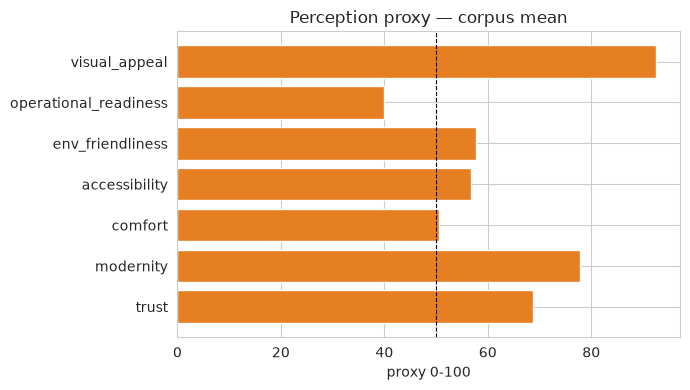

wrote blank coder template: /home/u_admin/ev_bus/Phase_2_Image_Analytics/data/perception_coding_template.csv (39, 11)


In [8]:
pxy = [f"pxy_{d}" for d in L.PERCEPTION_DIMS]
display(df[["image_id"]+pxy].head(8))
plt.figure(figsize=(7,4))
plt.barh(L.PERCEPTION_DIMS, [df[c].mean() for c in pxy], color="#e67e22")
plt.axvline(50, color="k", ls="--", lw=.8); plt.xlabel("proxy 0-100"); plt.title("Perception proxy — corpus mean")
plt.tight_layout(); plt.savefig(CHARTS/"fig_perception_proxy.png", dpi=140); plt.show()

tmpl = L.perception_template(df)
tmpl.to_csv(DATA/"perception_coding_template.csv", index=False)
print("wrote blank coder template:", DATA/"perception_coding_template.csv", tmpl.shape)

## 5. Feature → perception relationships

The five spec hypotheses. Each is a group comparison or Spearman correlation on the perception column (proxy by default).

In [9]:
tests = L.hypothesis_tests(df, perception_prefix="pxy_")
rows = []
for t in tests:
    r = t["result"]; direction = ""
    if isinstance(r, dict) and r.get("delta") is not None:
        direction = f"Δ={r['delta']:+} ({'supports' if r['delta']>0 else 'against'})"
    elif isinstance(r, dict) and r.get("rho") is not None:
        direction = f"ρ={r['rho']:+} p={r['p']} ({'supports' if r['rho']>0 else 'against'})"
    rows.append({"id":t["id"],"question":t["question"],"result":direction})
pd.DataFrame(rows)

,id,question,result
0,H1,Does real-operation imagery increase trust?,Δ=+3.3 (supports)
1,H2,Do bright interiors improve comfort perception?,ρ=+0.255 p=0.1175 (supports)
2,H3,Does charging visibility improve technology pe...,Δ=+18.7 (supports)
3,H4,Do passengers make images more relatable?,Δ=-11.3 (against)
4,H5,Does accessibility visibility improve brand in...,Δ=+15.9 (supports)


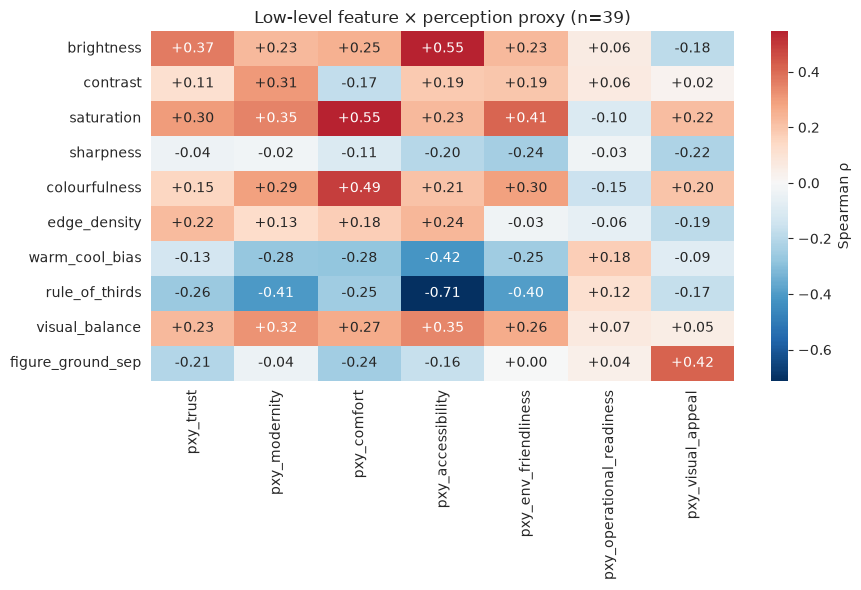

In [10]:
# low-level feature x perception proxy correlation heatmap
lowf = ["brightness","contrast","saturation","sharpness","colourfulness","edge_density",
        "warm_cool_bias","rule_of_thirds","visual_balance","figure_ground_sep"]
corr = df[lowf+pxy].corr(method="spearman").loc[lowf, pxy]
plt.figure(figsize=(9,6))
sns.heatmap(corr, annot=True, fmt="+.2f", cmap="RdBu_r", center=0, cbar_kws={"label":"Spearman ρ"})
plt.title(f"Low-level feature × perception proxy (n={len(df)})")
plt.tight_layout(); plt.savefig(CHARTS/"fig_feature_perception_corr.png", dpi=140); plt.show()

## 6. Save structured outputs

In [11]:
df["ar_bucket"] = df["aspect_ratio"].apply(lambda r: "portrait (<0.9)" if r<0.9 else ("landscape (>1.1)" if r>1.1 else "square (~1:1)"))
df.to_csv(DATA/"ev_bus_image_analysis.csv", index=False)

meta_cols = ["brightness","contrast","saturation","sharpness","colourfulness","edge_density",
             "warm_cool_bias","palette_family","hl_setting","hl_bus_visible","hl_passenger_driver_visible",
             "hl_charger_depot_flag","hl_accessibility_flag","hl_fleet_scale_deploy","hl_operational_proof_flag",
             "obj_bus_count","obj_person_count","nf_label","nf_compound"] + pxy
with open(DATA/"image_rag_documents.jsonl","w",encoding="utf-8") as f:
    for _, r in df.iterrows():
        doc = {"doc_id":r["image_id"],"modality":"image","file_path":r["file_path"],
               "text_for_index":f"CAPTION: {r.get('blip_caption','')}\nOCR: {r.get('ocr_text','')}",
               "metadata":{k:(None if (isinstance(r.get(k),float) and pd.isna(r.get(k))) else r.get(k)) for k in meta_cols}}
        f.write(json.dumps(doc, ensure_ascii=False, default=str)+"\n")

with open(REPORTS/"feature_perception_tests.json","w") as f: json.dump(tests, f, indent=2, default=str)
print("Wrote:")
for p in ["data/ev_bus_image_analysis.csv","data/image_rag_documents.jsonl",
          "data/perception_coding_template.csv","outputs/reports/feature_perception_tests.json"]:
    print("  ", p)
print("\nmaster table:", df.shape, "| columns:", list(df.columns))

Wrote:
   data/ev_bus_image_analysis.csv
   data/image_rag_documents.jsonl
   data/perception_coding_template.csv
   outputs/reports/feature_perception_tests.json

master table: (39, 67) | columns: ['image_id', 'file_path', 'width', 'height', 'aspect_ratio', 'file_size_kb', 'brightness', 'contrast', 'saturation', 'sharpness', 'warm_cool_bias', 'colourfulness', 'edge_density', 'symmetry_h', 'symmetry_v', 'rule_of_thirds', 'visual_balance', 'figure_ground_sep', 'top_color_rgb', 'top_color_share', 'palette_family', 'dominant_colors', 'blip_caption', 'ocr_text', 'obj_bus_count', 'obj_person_count', 'obj_truck_count', 'obj_all', 'hl_charger_depot', 'hl_charger_depot_flag', 'hl_accessibility', 'hl_accessibility_flag', 'hl_bus_in_motion', 'hl_bus_in_motion_flag', 'hl_fleet_scale', 'hl_fleet_scale_flag', 'hl_govt_handover', 'hl_govt_handover_flag', 'hl_operational_proof', 'hl_operational_proof_flag', 'theme_technology', 'theme_technology_flag', 'theme_comfort', 'theme_comfort_flag', 'theme_tru

### Output artefacts

| File | Contents |
|---|---|
| `data/ev_bus_image_analysis.csv` | master table — 1 row/image, all low- + high-level + text + proxy features |
| `data/image_rag_documents.jsonl` | RAG-ready docs (handoff to Phase 3) |
| `data/perception_coding_template.csv` | **blank** sheet for human/independent coders (1-7 Likert) |
| `outputs/reports/feature_perception_tests.{json,md}` | the five hypothesis tests |
| `outputs/reports/summary_stats.json` | corpus-level summary |
| `outputs/reports/feature_dictionary.md` | what every column means |
| `outputs/charts/*.png` | feature distributions, high-level flags, setting mix, perception proxy, feature×perception heatmap |

**To use real perception scores:** have coders fill `perception_coding_template.csv`, load it, join on `image_id`, and re-run `L.hypothesis_tests(df, perception_prefix="coder_")`.
